Starting Phase II simulation...
PHASE II: Emergent Market Dynamics
Initializing market simulator...
Running 5000-step simulation...
Starting 5000-step simulation with 61 agents...
Step 0/5000
Step 1000/5000
Step 2000/5000
Step 3000/5000
Step 4000/5000
Simulation complete!

Saving simulation data...
  Sampling LOB snapshots for storage...

Creating visualizations...
  Creating order book heatmap...
  Creating market statistics dashboard...
    Error creating statistics dashboard: '[5000] not in index'
  Creating additional diagnostics...

SIMULATION SUMMARY

Market Statistics:
  Total simulation steps: 5001
  Total trades: 2966
  Average spread: 0.7310
  Price range: 99.78 - 100.58

Return Statistics:
  Mean return: 0.000001
  Return volatility: 0.000463
  Skewness: 0.0379
  Kurtosis: 45.0858

Agent Performance Summary:
  Agent 0 (RLAgent): PnL = $-265.69, Trades = 282
  Agent 1 (MarketMaker): PnL = $-401.78, Trades = 0
  Agent 2 (MarketMaker): PnL = $401.78, Trades = 0
  Agent 3 (Marke

Traceback (most recent call last):
  File "C:\Users\Aratt\AppData\Local\Temp\ipykernel_24068\1400989959.py", line 1556, in <module>
    analyze_simulation_results(results)
  File "C:\Users\Aratt\AppData\Local\Temp\ipykernel_24068\1400989959.py", line 1424, in analyze_simulation_results
    print(f"    {'✓ Present' if has_fat_tails else '✗ Weak or absent'}")
  File "C:\Users\Aratt\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2713' in position 4: character maps to <undefined>


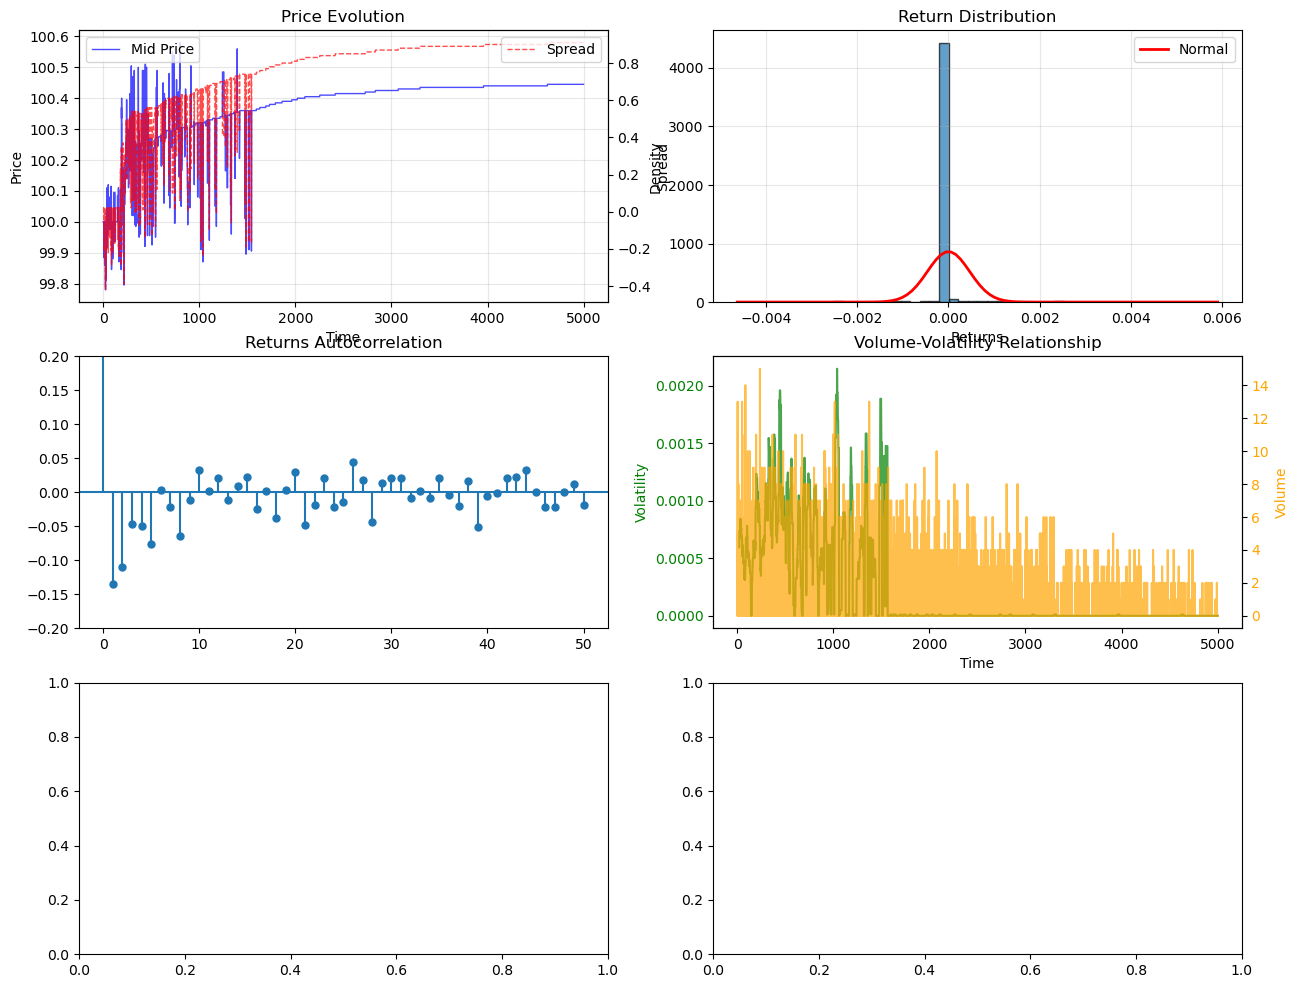

In [24]:
"""
PHASE II: Emergent Market Dynamics - Complete Implementation with All Fixes
"""

import numpy as np
import pandas as pd
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass
from enum import Enum
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import pickle
import json
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. DATA STRUCTURES
# ============================================================================

class OrderType(Enum):
    LIMIT_BUY = 1
    LIMIT_SELL = 2
    MARKET_BUY = 3
    MARKET_SELL = 4
    CANCEL = 5

@dataclass
class Order:
    """Atomic market order representation"""
    order_id: int
    agent_id: int
    order_type: OrderType
    price: Optional[float]  # None for market orders
    quantity: int
    timestamp: int
    expiration: Optional[int] = None
    
@dataclass  
class Trade:
    """Record of completed transaction"""
    trade_id: int
    buyer_id: int
    seller_id: int
    price: float
    quantity: int
    timestamp: int
    bid_price: Optional[float]  # Best bid at time of trade
    ask_price: Optional[float]  # Best ask at time of trade

# ============================================================================
# 2. ORDER BOOK IMPLEMENTATION
# ============================================================================

class OrderBook:
    """Double-auction limit order book implementation"""
    def __init__(self, tick_size: float = 0.01, max_levels: int = 100):
        self.tick_size = tick_size
        self.max_levels = max_levels
        
        # Core data structures
        self.bids = defaultdict(list)  # price -> [orders]
        self.asks = defaultdict(list)  # price -> [orders]
        self.order_map = {}  # order_id -> (price, side, index)
        
        # Market state
        self.last_trade = None
        self.trades = []
        self.order_id_counter = 0
        
        # Initialize with some orders to prevent empty book
        self._initialize_book()
        
    def _initialize_book(self):
        """Initialize order book with some resting orders"""
        initial_price = 100.0
        for i in range(5):
            # Add some initial bids
            bid_price = initial_price - (i + 1) * self.tick_size
            self.bids[bid_price] = []
            
            # Add some initial asks
            ask_price = initial_price + (i + 1) * self.tick_size
            self.asks[ask_price] = []
    
    def add_order(self, order: Order) -> List[Trade]:
        """Process order addition with price-time priority"""
        trades = []
        
        if order.order_type == OrderType.LIMIT_BUY:
            trades = self._match_buy_order(order)
            if order.quantity > 0:
                self._add_to_book(order, self.bids, 'bid')
                
        elif order.order_type == OrderType.LIMIT_SELL:
            trades = self._match_sell_order(order)
            if order.quantity > 0:
                self._add_to_book(order, self.asks, 'ask')
                
        elif order.order_type == OrderType.MARKET_BUY:
            trades = self._execute_market_buy(order)
            
        elif order.order_type == OrderType.MARKET_SELL:
            trades = self._execute_market_sell(order)
            
        return trades
    
    def _match_buy_order(self, order: Order) -> List[Trade]:
        """Match buy order against existing asks"""
        trades = []
        ask_prices = sorted(self.asks.keys())
        
        for price in ask_prices:
            # For limit orders, stop if price is too high
            if order.order_type == OrderType.LIMIT_BUY and price > order.price:
                break
                
            while self.asks.get(price) and order.quantity > 0:
                resting_order = self.asks[price][0]
                trade_qty = min(order.quantity, resting_order.quantity)
                
                # Execute trade
                trade = Trade(
                    trade_id=len(self.trades),
                    buyer_id=order.agent_id,
                    seller_id=resting_order.agent_id,
                    price=price,
                    quantity=trade_qty,
                    timestamp=order.timestamp,
                    bid_price=self.best_bid(),
                    ask_price=self.best_ask()
                )
                trades.append(trade)
                self.trades.append(trade)
                self.last_trade = trade
                
                # Update quantities
                order.quantity -= trade_qty
                resting_order.quantity -= trade_qty
                
                # Remove filled order
                if resting_order.quantity == 0:
                    self.asks[price].pop(0)
                    del self.order_map[resting_order.order_id]
                    if not self.asks[price]:
                        del self.asks[price]
                        
            if order.quantity == 0:
                break
                
        return trades
    
    def _match_sell_order(self, order: Order) -> List[Trade]:
        """Match sell order against existing bids"""
        trades = []
        bid_prices = sorted(self.bids.keys(), reverse=True)  # Highest first
        
        for price in bid_prices:
            # For limit orders, stop if price is too low
            if order.order_type == OrderType.LIMIT_SELL and price < order.price:
                break
                
            while self.bids.get(price) and order.quantity > 0:
                resting_order = self.bids[price][0]
                trade_qty = min(order.quantity, resting_order.quantity)
                
                # Execute trade
                trade = Trade(
                    trade_id=len(self.trades),
                    buyer_id=resting_order.agent_id,
                    seller_id=order.agent_id,
                    price=price,
                    quantity=trade_qty,
                    timestamp=order.timestamp,
                    bid_price=self.best_bid(),
                    ask_price=self.best_ask()
                )
                trades.append(trade)
                self.trades.append(trade)
                self.last_trade = trade
                
                # Update quantities
                order.quantity -= trade_qty
                resting_order.quantity -= trade_qty
                
                # Remove filled order
                if resting_order.quantity == 0:
                    self.bids[price].pop(0)
                    del self.order_map[resting_order.order_id]
                    if not self.bids[price]:
                        del self.bids[price]
                        
            if order.quantity == 0:
                break
                
        return trades
    
    def _execute_market_buy(self, order: Order) -> List[Trade]:
        """Execute market buy order (immediate execution)"""
        return self._match_buy_order(order)
    
    def _execute_market_sell(self, order: Order) -> List[Trade]:
        """Execute market sell order (immediate execution)"""
        return self._match_sell_order(order)
    
    def _add_to_book(self, order: Order, book: Dict, side: str):
        """Add resting order to the book"""
        price = order.price
        book[price].append(order)
        self.order_map[order.order_id] = (price, side, len(book[price]) - 1)
    
    def best_bid(self) -> Optional[float]:
        if self.bids:
            return max(self.bids.keys())
        return 99.5  # Default if no bids
    
    def best_ask(self) -> Optional[float]:
        if self.asks:
            return min(self.asks.keys())
        return 100.5  # Default if no asks
        
    def mid_price(self) -> float:
        bid, ask = self.best_bid(), self.best_ask()
        return (bid + ask) / 2
        
    def spread(self) -> float:
        bid, ask = self.best_bid(), self.best_ask()
        return ask - bid
    
    def get_depth(self, levels: int = 5) -> Dict:
        """Get order book depth up to specified levels"""
        depth = {
            'bids': [],
            'asks': []
        }
        
        # Get top bid levels
        bid_prices = sorted(self.bids.keys(), reverse=True)[:levels]
        for price in bid_prices:
            total_volume = sum(order.quantity for order in self.bids[price])
            depth['bids'].append({'price': price, 'volume': total_volume})
            
        # Get top ask levels
        ask_prices = sorted(self.asks.keys())[:levels]
        for price in ask_prices:
            total_volume = sum(order.quantity for order in self.asks[price])
            depth['asks'].append({'price': price, 'volume': total_volume})
            
        return depth

# ============================================================================
# 3. AGENT IMPLEMENTATIONS (COMPLETE WITH ALL METHODS)
# ============================================================================

class BaseAgent:
    """Abstract agent interface"""
    def __init__(self, agent_id: int, initial_cash: float = 10000.0, initial_inventory: int = 0):
        self.agent_id = agent_id
        self.cash = initial_cash
        self.inventory = initial_inventory
        self.position_limit = 100  # Max absolute inventory
        self.order_history = []
        self.trade_history = []
        self.pnl_history = []
        
    def act(self, market_state: Dict) -> List[Order]:
        """Generate orders based on market state"""
        raise NotImplementedError
    
    def update_pnl(self, current_price: float):
        """Calculate current P&L"""
        if current_price is None:
            return 0.0
        pnl = self.cash + self.inventory * current_price
        self.pnl_history.append(pnl)
        return pnl
    
    def get_state(self) -> Dict:
        """Get agent's current state"""
        return {
            'agent_id': self.agent_id,
            'cash': self.cash,
            'inventory': self.inventory,
            'position_limit': self.position_limit,
            'num_orders': len(self.order_history),
            'num_trades': len(self.trade_history)
        }

class NoiseTrader(BaseAgent):
    """Zero-intelligence agent for stochastic order flow"""
    def __init__(self, agent_id: int, initial_cash: float = 10000.0, 
                 initial_inventory: int = 0, noise_intensity: float = 0.1):
        super().__init__(agent_id, initial_cash, initial_inventory)
        self.noise_intensity = noise_intensity
        self.mean_reversion_factor = 0.05
        self.last_action_time = -10  # Start negative so agents can act immediately
        
    def act(self, market_state: Dict) -> List[Order]:
        orders = []
        mid_price = market_state.get('mid_price', 100.0)
        timestamp = market_state.get('timestamp', 0)
        
        # Random trading impulse with some time between actions
        if (timestamp - self.last_action_time > np.random.poisson(5) and 
            np.random.random() < self.noise_intensity):
            
            # Mean reversion tendency
            target_inventory = 0
            inventory_imbalance = target_inventory - self.inventory
            
            # Price pressure from inventory
            price_adjustment = -inventory_imbalance * self.mean_reversion_factor / 100
            
            # Determine order parameters
            if np.random.random() < 0.5 + 0.3 * np.tanh(inventory_imbalance / 20):
                # Buy order
                price = mid_price * (1 + price_adjustment + np.random.normal(0, 0.001))
                qty = min(np.random.randint(1, 5), self.position_limit - self.inventory)
                if qty > 0:
                    order = Order(
                        order_id=np.random.randint(1, 10**9),
                        agent_id=self.agent_id,
                        order_type=OrderType.LIMIT_BUY,
                        price=round(price / 0.01) * 0.01,  # Round to tick
                        quantity=qty,
                        timestamp=timestamp
                    )
                    orders.append(order)
                    self.order_history.append(order)
            else:
                # Sell order
                price = mid_price * (1 + price_adjustment + np.random.normal(0, 0.001))
                qty = min(np.random.randint(1, 5), self.inventory + self.position_limit)
                if qty > 0:
                    order = Order(
                        order_id=np.random.randint(1, 10**9),
                        agent_id=self.agent_id,
                        order_type=OrderType.LIMIT_SELL,
                        price=round(price / 0.01) * 0.01,
                        quantity=qty,
                        timestamp=timestamp
                    )
                    orders.append(order)
                    self.order_history.append(order)
            
            self.last_action_time = timestamp
                    
        return orders

class MarketMaker(BaseAgent):
    """Passive liquidity provider earning spread"""
    def __init__(self, agent_id: int, initial_cash: float = 50000.0, 
                 initial_inventory: int = 0, spread_target: float = 0.02):
        super().__init__(agent_id, initial_cash, initial_inventory)
        self.spread_target = spread_target
        self.quote_size = 5
        self.inventory_target = 0
        self.active_orders = {}  # order_id -> Order
        self.last_quote_time = -10
        
    def _cancel_stale_orders(self, market_state: Dict) -> List[Order]:
        """Cancel orders that have been resting too long"""
        orders = []
        current_time = market_state.get('timestamp', 0)
        
        # Cancel orders older than 20 timesteps
        orders_to_cancel = []
        for order_id, order in list(self.active_orders.items()):
            if current_time - order.timestamp > 20:
                orders_to_cancel.append(order_id)
                
        for order_id in orders_to_cancel:
            order = self.active_orders[order_id]
            cancel_order = Order(
                order_id=np.random.randint(1, 10**9),
                agent_id=self.agent_id,
                order_type=OrderType.CANCEL,
                price=order.price,
                quantity=order.quantity,
                timestamp=current_time
            )
            orders.append(cancel_order)
            del self.active_orders[order_id]
            
        return orders
        
    def act(self, market_state: Dict) -> List[Order]:
        orders = []
        mid_price = market_state.get('mid_price', 100.0)
        timestamp = market_state.get('timestamp', 0)
        
        # Only quote every 5 timesteps to avoid excessive activity
        if timestamp - self.last_quote_time < 5:
            return orders
            
        # Cancel old orders
        cancel_orders = self._cancel_stale_orders(market_state)
        orders.extend(cancel_orders)
        
        # Adjust spread based on inventory
        inventory_skew = self.inventory / self.position_limit if self.position_limit > 0 else 0
        spread_adjustment = 1 + 2 * abs(inventory_skew)  # Widen spread when imbalanced
        
        # Post new quotes
        bid_price = mid_price * (1 - self.spread_target * spread_adjustment / 2)
        ask_price = mid_price * (1 + self.spread_target * spread_adjustment / 2)
        
        # Round to tick size
        bid_price = round(bid_price / 0.01) * 0.01
        ask_price = round(ask_price / 0.01) * 0.01
        
        # Post bid if not too long
        if self.inventory < self.position_limit:
            bid_order = Order(
                order_id=np.random.randint(1, 10**9),
                agent_id=self.agent_id,
                order_type=OrderType.LIMIT_BUY,
                price=bid_price,
                quantity=self.quote_size,
                timestamp=timestamp
            )
            orders.append(bid_order)
            self.order_history.append(bid_order)
            self.active_orders[bid_order.order_id] = bid_order
            
        # Post ask if not too short
        if self.inventory > -self.position_limit:
            ask_order = Order(
                order_id=np.random.randint(1, 10**9),
                agent_id=self.agent_id,
                order_type=OrderType.LIMIT_SELL,
                price=ask_price,
                quantity=self.quote_size,
                timestamp=timestamp
            )
            orders.append(ask_order)
            self.order_history.append(ask_order)
            self.active_orders[ask_order.order_id] = ask_order
            
        self.last_quote_time = timestamp
        
        return orders

class RLAgent(BaseAgent):
    """Trained PPO agent operating in the multi-agent environment"""
    def __init__(self, agent_id: int, initial_cash: float = 100000.0, 
                 initial_inventory: int = 0, policy_path: str = None):
        super().__init__(agent_id, initial_cash, initial_inventory)
        
        # Load pre-trained policy or use default
        if policy_path and Path(policy_path).exists():
            self.policy = self._load_policy(policy_path)
        else:
            # Default simple policy if no trained model
            self.policy = self._default_policy
            
        self.state_history = []
        self.action_history = []
        self.feature_history = []
        self.last_action = 'hold'
        self.action_counter = {'buy': 0, 'sell': 0, 'hold': 0, 'limit_buy': 0, 'limit_sell': 0}
        
    def _load_policy(self, policy_path: str):
        """Load trained policy from file"""
        # Simplified policy loader - in practice would load actual model
        def simple_policy(state_features):
            # Basic mean reversion strategy
            price_trend = state_features.get('price_trend', 0)
            inventory_ratio = state_features.get('inventory_ratio', 0)
            
            if price_trend < -0.01 and inventory_ratio < 0.8:
                return 'buy'
            elif price_trend > 0.01 and inventory_ratio > -0.8:
                return 'sell'
            elif abs(inventory_ratio) > 0.5:
                return 'limit_buy' if inventory_ratio < 0 else 'limit_sell'
            else:
                return 'hold'
                
        return simple_policy
    
    def _default_policy(self, state_features):
        """Default policy when no trained model available"""
        # Simple inventory-based mean reversion
        inventory_ratio = state_features.get('inventory_ratio', 0)
        
        if np.random.random() < 0.1:  # 10% chance to act
            if inventory_ratio < -0.3:
                return 'buy' if np.random.random() < 0.7 else 'limit_buy'
            elif inventory_ratio > 0.3:
                return 'sell' if np.random.random() < 0.7 else 'limit_sell'
            elif np.random.random() < 0.5:
                return 'buy' if np.random.random() < 0.5 else 'sell'
                
        return 'hold'
    
    def _extract_features(self, market_state: Dict) -> Dict:
        """Extract relevant features for policy decision"""
        mid_price = market_state.get('mid_price', 100.0)
        spread = market_state.get('spread', 0.02)
        
        features = {
            'mid_price': mid_price,
            'spread': spread,
            'spread_ratio': spread / mid_price,
            'inventory_ratio': self.inventory / self.position_limit if self.position_limit > 0 else 0,
            'cash_ratio': self.cash / 100000.0,
            'volume': market_state.get('volume', 0),
            'timestamp': market_state.get('timestamp', 0)
        }
        
        # Add price trend if we have history
        if len(self.feature_history) > 0:
            last_price = self.feature_history[-1].get('mid_price', 100.0)
            features['price_trend'] = (features['mid_price'] - last_price) / last_price
        else:
            features['price_trend'] = 0.0
            
        # Add momentum
        if len(self.feature_history) > 4:
            recent_prices = [f.get('mid_price', 100.0) for f in self.feature_history[-5:]]
            features['momentum'] = (features['mid_price'] - recent_prices[0]) / recent_prices[0]
        else:
            features['momentum'] = 0.0
            
        return features
        
    def act(self, market_state: Dict) -> List[Order]:
        """Generate orders using learned policy"""
        orders = []
        
        # Extract features for policy
        state_features = self._extract_features(market_state)
        self.feature_history.append(state_features)
        self.state_history.append(state_features)
        
        # Get action from policy
        action = self.policy(state_features)
        self.action_history.append(action)
        self.action_counter[action] = self.action_counter.get(action, 0) + 1
        self.last_action = action
        
        # Map action to order
        mid_price = market_state.get('mid_price', 100.0)
            
        if action == 'buy' and self.inventory < self.position_limit:
            # Aggressive buying - market order
            qty = min(2, self.position_limit - self.inventory)
            if qty > 0:
                order = Order(
                    order_id=np.random.randint(1, 10**9),
                    agent_id=self.agent_id,
                    order_type=OrderType.MARKET_BUY,
                    price=None,
                    quantity=qty,
                    timestamp=market_state.get('timestamp', 0)
                )
                orders.append(order)
                self.order_history.append(order)
            
        elif action == 'sell' and self.inventory > -self.position_limit:
            # Aggressive selling - market order
            qty = min(2, self.inventory + self.position_limit)
            if qty > 0:
                order = Order(
                    order_id=np.random.randint(1, 10**9),
                    agent_id=self.agent_id,
                    order_type=OrderType.MARKET_SELL,
                    price=None,
                    quantity=qty,
                    timestamp=market_state.get('timestamp', 0)
                )
                orders.append(order)
                self.order_history.append(order)
            
        elif action == 'limit_buy' and self.inventory < self.position_limit:
            # Passive buying - limit order
            price = mid_price * 0.995  # Slightly below mid
            qty = min(1, self.position_limit - self.inventory)
            if qty > 0:
                order = Order(
                    order_id=np.random.randint(1, 10**9),
                    agent_id=self.agent_id,
                    order_type=OrderType.LIMIT_BUY,
                    price=round(price / 0.01) * 0.01,
                    quantity=qty,
                    timestamp=market_state.get('timestamp', 0)
                )
                orders.append(order)
                self.order_history.append(order)
                
        elif action == 'limit_sell' and self.inventory > -self.position_limit:
            # Passive selling - limit order
            price = mid_price * 1.005  # Slightly above mid
            qty = min(1, self.inventory + self.position_limit)
            if qty > 0:
                order = Order(
                    order_id=np.random.randint(1, 10**9),
                    agent_id=self.agent_id,
                    order_type=OrderType.LIMIT_SELL,
                    price=round(price / 0.01) * 0.01,
                    quantity=qty,
                    timestamp=market_state.get('timestamp', 0)
                )
                orders.append(order)
                self.order_history.append(order)
            
        return orders

# ============================================================================
# 4. SIMULATION ENGINE (UPDATED)
# ============================================================================

class MarketSimulator:
    """Orchestrates multi-agent market simulation"""
    def __init__(self, config: Dict):
        self.config = config
        self.order_book = OrderBook(
            tick_size=config.get('tick_size', 0.01),
            max_levels=config.get('max_levels', 100)
        )
        
        # Initialize agents
        self.agents = self._initialize_agents()
        
        # Data collection
        self.market_data = []
        self.order_flow = []
        self.lob_snapshots = []
        
        # Simulation state
        self.timestamp = 0
        self.fundamental_value = 100.0  # Arbitrary starting price
        
    def _initialize_agents(self) -> List[BaseAgent]:
        """Create heterogeneous agent population"""
        agents = []
        agent_id = 0
        
        # RL Agent
        agents.append(RLAgent(
            agent_id=agent_id,
            initial_cash=100000,
            initial_inventory=0,
            policy_path=self.config.get('rl_policy_path')
        ))
        agent_id += 1
        
        # Market Makers (10 agents)
        for i in range(10):
            agents.append(MarketMaker(
                agent_id=agent_id,
                initial_cash=50000,
                initial_inventory=np.random.randint(-10, 10),
                spread_target=np.random.uniform(0.01, 0.03)
            ))
            agent_id += 1
            
        # Noise Traders (50 agents)
        for i in range(50):
            agents.append(NoiseTrader(
                agent_id=agent_id,
                initial_cash=10000,
                initial_inventory=np.random.randint(-20, 20),
                noise_intensity=np.random.uniform(0.05, 0.2)
            ))
            agent_id += 1
            
        return agents
    
    def _get_market_state(self) -> Dict:
        """Current observable market state"""
        mid_price = self.order_book.mid_price()
        best_bid = self.order_book.best_bid()
        best_ask = self.order_book.best_ask()
        spread = self.order_book.spread()
        
        return {
            'timestamp': self.timestamp,
            'mid_price': mid_price,
            'best_bid': best_bid,
            'best_ask': best_ask,
            'spread': spread,
            'last_trade': self.order_book.last_trade.price 
                if self.order_book.last_trade else None,
            'fundamental_value': self.fundamental_value,
            'volume': sum(t.quantity for t in self.order_book.trades 
                         if t.timestamp == self.timestamp - 1) if self.timestamp > 0 else 0,
            'order_book_depth': self.order_book.get_depth(levels=3)
        }
        
    def step(self):
        """Execute one simulation step"""
        # Update fundamental value (random walk with drift)
        self.fundamental_value *= np.exp(
            np.random.normal(0.0001, 0.01)  # 0.01% daily drift, 1% volatility
        )
        
        # Collect market state
        market_state = self._get_market_state()
        
        # Agents submit orders
        all_orders = []
        for agent in self.agents:
            try:
                orders = agent.act(market_state)
                for order in orders:
                    # Only process valid orders
                    if order is not None:
                        all_orders.append(order)
            except Exception as e:
                print(f"Error in agent {agent.agent_id} act method: {e}")
                continue
            
        # Shuffle orders to avoid bias
        np.random.shuffle(all_orders)
        
        # Process orders sequentially
        for order in all_orders:
            if order is None:
                continue
                
            if order.order_type == OrderType.CANCEL:
                # Handle order cancellation
                pass  # Simplified - in full implementation would remove from book
            else:
                trades = self.order_book.add_order(order)
                
                # Update agents with trade executions
                for trade in trades:
                    buyer_id = trade.buyer_id
                    seller_id = trade.seller_id
                    
                    if buyer_id < len(self.agents):
                        buyer = self.agents[buyer_id]
                        buyer.cash -= trade.price * trade.quantity
                        buyer.inventory += trade.quantity
                        buyer.trade_history.append(trade)
                    
                    if seller_id < len(self.agents):
                        seller = self.agents[seller_id]
                        seller.cash += trade.price * trade.quantity
                        seller.inventory -= trade.quantity
                        seller.trade_history.append(trade)
                    
                # Log order flow
                self.order_flow.append({
                    'timestamp': self.timestamp,
                    'order_id': order.order_id,
                    'agent_id': order.agent_id,
                    'type': order.order_type.name,
                    'price': order.price,
                    'quantity': order.quantity,
                    'filled': sum(t.quantity for t in trades if t.buyer_id == order.agent_id 
                                 or t.seller_id == order.agent_id)
                })
        
        # Capture market snapshot
        self._capture_snapshot()
        
        self.timestamp += 1
        
    def _capture_snapshot(self):
        """Record full limit order book state"""
        # Aggregate bid volumes
        bid_volumes = {}
        for price, orders in self.order_book.bids.items():
            bid_volumes[price] = sum(order.quantity for order in orders)
            
        # Aggregate ask volumes
        ask_volumes = {}
        for price, orders in self.order_book.asks.items():
            ask_volumes[price] = sum(order.quantity for order in orders)
        
        snapshot = {
            'timestamp': self.timestamp,
            'bids': bid_volumes,
            'asks': ask_volumes,
            'mid_price': self.order_book.mid_price(),
            'spread': self.order_book.spread(),
            'trades': [t for t in self.order_book.trades 
                      if t.timestamp == self.timestamp]
        }
        self.lob_snapshots.append(snapshot)
        
        # Also store aggregated market data
        market_state = self._get_market_state()
        market_state['fundamental_value'] = self.fundamental_value
        self.market_data.append(market_state)
        
    def run(self, n_steps: int = 5000):
        """Execute full simulation"""
        print(f"Starting {n_steps}-step simulation with {len(self.agents)} agents...")
        
        # Initial market data point
        self._capture_snapshot()
        
        for step in range(n_steps):
            if step % 1000 == 0:
                print(f"Step {step}/{n_steps}")
                
            self.step()
            
        print("Simulation complete!")
        return self._compile_results()
        
    def _compile_results(self) -> Dict:
        """Organize simulation outputs"""
        # Compile trades
        trades_data = []
        for trade in self.order_book.trades:
            trades_data.append({
                'timestamp': trade.timestamp,
                'price': trade.price,
                'quantity': trade.quantity,
                'buyer': trade.buyer_id,
                'seller': trade.seller_id,
                'spread': trade.ask_price - trade.bid_price if trade.bid_price and trade.ask_price else None
            })
        
        # Compile agent states
        agent_states = {}
        final_price = 100.0  # Default final price
        
        # Get a valid final price from market data
        if self.market_data:
            # Find the last non-None mid_price
            for data_point in reversed(self.market_data):
                if data_point.get('mid_price') is not None:
                    final_price = data_point['mid_price']
                    break
        
        for agent in self.agents:
            pnl = agent.cash + agent.inventory * final_price
            initial_cash = 100000 if isinstance(agent, RLAgent) else \
                          (50000 if isinstance(agent, MarketMaker) else 10000)
            
            agent_states[agent.agent_id] = {
                'type': agent.__class__.__name__,
                'final_cash': agent.cash,
                'final_inventory': agent.inventory,
                'total_trades': len(agent.trade_history),
                'total_orders': len(agent.order_history),
                'final_pnl': pnl,
                'initial_cash': initial_cash,
                'pnl_change': pnl - initial_cash
            }
        
        return {
            'market_data': pd.DataFrame(self.market_data),
            'order_flow': pd.DataFrame(self.order_flow) if self.order_flow else pd.DataFrame(),
            'lob_snapshots': self.lob_snapshots,
            'trades': pd.DataFrame(trades_data) if trades_data else pd.DataFrame(),
            'agent_states': agent_states,
            'config': self.config
        }

# ============================================================================
# 5. VISUALIZATION TOOLS (UPDATED)
# ============================================================================

class MarketVisualizer:
    """Specialized visualization for market microstructure"""
    
    @staticmethod
    def plot_orderbook_heatmap(lob_snapshots: List[Dict], 
                              price_range: Tuple[float, float] = None,
                              time_window: Tuple[int, int] = None,
                              step_size: int = 10):
        """
        Create heatmap of resting order volumes
        
        Parameters:
        -----------
        lob_snapshots: List of limit order book snapshots
        price_range: (min_price, max_price) to display
        time_window: (start_time, end_time) to display
        step_size: Sample every nth snapshot to reduce data
        """
        
        # Extract data
        times = []
        price_levels = []
        volumes = []
        
        # Sample snapshots to reduce data
        sampled_snapshots = lob_snapshots[::step_size]
        
        for snapshot in sampled_snapshots:
            t = snapshot['timestamp']
            
            # Apply time filter
            if time_window and not (time_window[0] <= t <= time_window[1]):
                continue
                
            # Aggregate bid volumes
            for price, volume in snapshot.get('bids', {}).items():
                if price_range and not (price_range[0] <= price <= price_range[1]):
                    continue
                times.append(t)
                price_levels.append(price)
                volumes.append(volume)  # Positive for bids
                
            # Aggregate ask volumes
            for price, volume in snapshot.get('asks', {}).items():
                if price_range and not (price_range[0] <= price <= price_range[1]):
                    continue
                times.append(t)
                price_levels.append(price)
                volumes.append(-volume)  # Negative for asks
                
        if not times:  # No data to plot
            print("No data in selected range")
            return None, None, None
        
        # Create DataFrame
        df = pd.DataFrame({
            'time': times,
            'price': price_levels,
            'volume': volumes
        })
        
        if df.empty:
            print("Empty dataframe after filtering")
            return None, None, None
        
        # Create pivot table
        try:
            pivot = df.pivot_table(
                index='price',
                columns='time',
                values='volume',
                aggfunc='sum',
                fill_value=0
            )
            
            # Sort prices
            pivot = pivot.sort_index(ascending=False)
            
        except Exception as e:
            print(f"Error creating pivot table: {e}")
            # Fallback: use manual binning
            price_min, price_max = df['price'].min(), df['price'].max()
            price_bins = np.arange(price_min - 0.01, price_max + 0.02, 0.01)
            df['price_bin'] = pd.cut(df['price'], bins=price_bins, 
                                    labels=price_bins[:-1] + 0.005)
            
            pivot = df.pivot_table(
                index='price_bin',
                columns='time',
                values='volume',
                aggfunc='sum',
                fill_value=0
            )
        
        # Plot
        fig, ax = plt.subplots(figsize=(15, 10))
        
        # Use diverging colormap: red for asks, blue for bids
        cmap = plt.cm.RdBu_r
        vmax = max(abs(pivot.min().min()), abs(pivot.max().max()))
        vmax = max(vmax, 1)  # Ensure at least some color variation
        
        im = ax.imshow(
            pivot.values,
            aspect='auto',
            cmap=cmap,
            vmin=-vmax,
            vmax=vmax,
            extent=[df['time'].min(), df['time'].max(), 
                   0, len(pivot.index)],
            origin='lower'
        )
        
        # Add price labels on y-axis (sample some for readability)
        if len(pivot.index) > 0:
            n_labels = min(10, len(pivot.index))
            step = max(1, len(pivot.index) // n_labels)
            yticks = np.arange(0, len(pivot.index), step)
            
            # Get price labels
            if hasattr(pivot.index, 'categories'):  # Categorical index
                yticklabels = [f"{float(str(pivot.index[i])):.2f}" 
                              for i in range(0, len(pivot.index), step)]
            else:
                yticklabels = [f"{pivot.index[i]:.2f}" 
                              for i in range(0, len(pivot.index), step)]
            
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels)
        
        # Add mid-price line if available
        mid_prices = []
        times_mid = []
        for snap in sampled_snapshots:
            if snap.get('mid_price') is not None:
                # Find closest price bin
                price_bins = pivot.index
                if hasattr(price_bins, 'categories'):  # Categorical index
                    price_vals = price_bins.categories.astype(float)
                else:
                    price_vals = price_bins.astype(float)
                    
                if len(price_vals) > 0:
                    idx = np.abs(price_vals - snap['mid_price']).argmin()
                    mid_prices.append(idx)
                    times_mid.append(snap['timestamp'])
        
        if mid_prices:
            ax.plot(times_mid, mid_prices, 'k-', linewidth=2, label='Mid Price', alpha=0.7)
        
        # Formatting
        ax.set_xlabel('Time Step', fontsize=12)
        ax.set_ylabel('Price', fontsize=12)
        ax.set_title('Limit Order Book Heatmap', fontsize=14, fontweight='bold')
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Resting Volume (Bids + / Asks -)', fontsize=10)
        
        # Add legend
        if mid_prices:
            ax.legend(loc='upper right')
        
        plt.tight_layout()
        return fig, ax, pivot
    
    @staticmethod
    def plot_market_statistics(results: Dict):
        """Comprehensive market analysis plots"""
        
        market_data = results['market_data']
        
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        
        # 1. Price and Spread
        ax = axes[0, 0]
        if not market_data.empty and 'mid_price' in market_data.columns:
            ax.plot(market_data['timestamp'], market_data['mid_price'], 
                   'b-', label='Mid Price', alpha=0.7, linewidth=1)
            ax.set_xlabel('Time')
            ax.set_ylabel('Price')
            ax.set_title('Price Evolution')
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)
            
            if 'spread' in market_data.columns:
                ax2 = ax.twinx()
                ax2.plot(market_data['timestamp'], market_data['spread'], 
                        'r--', label='Spread', alpha=0.7, linewidth=1)
                ax2.set_ylabel('Spread')
                ax2.legend(loc='upper right')
        
        # 2. Returns Distribution
        ax = axes[0, 1]
        if not market_data.empty and 'mid_price' in market_data.columns:
            returns = market_data['mid_price'].pct_change().dropna()
            if len(returns) > 0:
                ax.hist(returns, bins=50, density=True, alpha=0.7, edgecolor='black')
                ax.set_xlabel('Returns')
                ax.set_ylabel('Density')
                ax.set_title('Return Distribution')
                ax.grid(True, alpha=0.3)
                
                # Overlay normal distribution for comparison
                x = np.linspace(returns.min(), returns.max(), 100)
                ax.plot(x, stats.norm.pdf(x, returns.mean(), returns.std()), 
                       'r-', label='Normal', linewidth=2)
                ax.legend()
        
        # 3. Autocorrelation of Returns
        ax = axes[1, 0]
        if not market_data.empty and 'mid_price' in market_data.columns:
            returns = market_data['mid_price'].pct_change().dropna()
            if len(returns) > 1:
                from statsmodels.graphics.tsaplots import plot_acf
                plot_acf(returns, ax=ax, lags=min(50, len(returns)-1), alpha=None)
                ax.set_title('Returns Autocorrelation')
                ax.set_ylim(-0.2, 0.2)
        
        # 4. Volume and Volatility
        ax = axes[1, 1]
        if not market_data.empty and 'mid_price' in market_data.columns:
            returns = market_data['mid_price'].pct_change().dropna()
            if len(returns) > 20:
                volatility = returns.rolling(20).std()
                
                # Calculate volume from trades
                trades = results.get('trades', pd.DataFrame())
                if not trades.empty:
                    volume = trades.groupby('timestamp')['quantity'].sum()
                    volume_aligned = volume.reindex(market_data['timestamp']).fillna(0)
                    
                    ax.plot(volatility.index, volatility.values, 
                           'g-', label='Rolling Volatility (20 steps)', alpha=0.7)
                    ax.set_xlabel('Time')
                    ax.set_ylabel('Volatility', color='g')
                    ax.tick_params(axis='y', labelcolor='g')
                    ax.set_title('Volume-Volatility Relationship')
                    
                    ax2 = ax.twinx()
                    ax2.plot(volume_aligned.index, volume_aligned.values, 
                            'orange', label='Trading Volume', alpha=0.7)
                    ax2.set_ylabel('Volume', color='orange')
                    ax2.tick_params(axis='y', labelcolor='orange')
                    
                    # Add correlation annotation
                    valid_idx = volatility.dropna().index
                    if len(valid_idx) > 0:
                        vol_vals = volatility.loc[valid_idx].values
                        vol_vol_vals = volume_aligned.loc[valid_idx].values
                        if len(vol_vals) > 1 and len(vol_vol_vals) > 1:
                            corr = np.corrcoef(vol_vals, vol_vol_vals)[0,1]
                            ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                                   transform=ax.transAxes, fontsize=10,
                                   verticalalignment='top',
                                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 5. Order Flow Imbalance
        ax = axes[2, 0]
        order_flow = results.get('order_flow', pd.DataFrame())
        if not order_flow.empty:
            order_flow['side'] = order_flow['type'].apply(
                lambda x: 1 if 'BUY' in x else (-1 if 'SELL' in x else 0)
            )
            imbalance = order_flow.groupby('timestamp')['side'].sum()
            
            if not imbalance.empty:
                ax.bar(imbalance.index, imbalance.values, alpha=0.7, width=0.8)
                ax.set_xlabel('Time')
                ax.set_ylabel('Order Flow Imbalance')
                ax.set_title('Buy-Sell Order Imbalance')
                ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
                ax.grid(True, alpha=0.3)
        
        # 6. Agent Inventory Distribution
        ax = axes[2, 1]
        agent_states = results.get('agent_states', {})
        if agent_states:
            inventories = []
            agent_types = []
            
            for agent_id, state in agent_states.items():
                inventories.append(state['final_inventory'])
                agent_types.append(state['type'])
            
            # Create histogram by agent type
            unique_types = list(set(agent_types))
            for agent_type in unique_types:
                type_inventories = [inv for inv, typ in zip(inventories, agent_types) 
                                   if typ == agent_type]
                if type_inventories:
                    ax.hist(type_inventories, alpha=0.5, label=agent_type, bins=20)
            
            ax.set_xlabel('Final Inventory')
            ax.set_ylabel('Frequency')
            ax.set_title('Agent Inventory Distribution')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig

# ============================================================================
# 6. COMPLETE EXECUTION PIPELINE (FIXED)
# ============================================================================

def run_phase_ii_simulation():
    """
    End-to-end execution of Phase II simulation
    """
    
    # Configuration
    config = {
        'tick_size': 0.01,
        'max_levels': 100,
        'rl_policy_path': None,  # Path to pre-trained PPO policy
        'seed': 42,
        'n_steps': 5000
    }
    
    np.random.seed(config['seed'])
    
    # Initialize simulator
    print("=" * 60)
    print("PHASE II: Emergent Market Dynamics")
    print("=" * 60)
    print("Initializing market simulator...")
    simulator = MarketSimulator(config)
    
    # Run simulation
    print(f"Running {config['n_steps']}-step simulation...")
    results = simulator.run(n_steps=config['n_steps'])
    
    # Save raw data
    print("\nSaving simulation data...")
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    output_dir = Path(f"simulation_results_{timestamp}")
    output_dir.mkdir(exist_ok=True)
    
    # Save market data
    results['market_data'].to_csv(output_dir / f'market_data.csv', index=False)
    
    if not results['order_flow'].empty:
        results['order_flow'].to_csv(output_dir / f'order_flow.csv', index=False)
    
    if not results['trades'].empty:
        results['trades'].to_csv(output_dir / f'trades.csv', index=False)
    
    # Save config
    with open(output_dir / 'config.json', 'w') as f:
        json.dump(config, f, indent=2)
    
    # Save LOB snapshots (compressed, sampled)
    print("  Sampling LOB snapshots for storage...")
    if results['lob_snapshots']:
        lob_sample = results['lob_snapshots'][::10]  # Take every 10th snapshot
        with open(output_dir / f'lob_snapshots_sample.pkl', 'wb') as f:
            pickle.dump(lob_sample, f)
    else:
        print("  Warning: No LOB snapshots to save")
    
    # Generate visualizations
    print("\nCreating visualizations...")
    visualizer = MarketVisualizer()
    
    # 1. Order Book Heatmap (for a subset of data)
    print("  Creating order book heatmap...")
    try:
        # Use first 1000 steps for heatmap to avoid memory issues
        if results['lob_snapshots']:
            heatmap_snapshots = [s for s in results['lob_snapshots'] if s['timestamp'] < 1000]
            if heatmap_snapshots:
                fig_heatmap, ax_heatmap, heatmap_data = visualizer.plot_orderbook_heatmap(
                    heatmap_snapshots,
                    time_window=(0, 1000)
                )
                if fig_heatmap:
                    fig_heatmap.savefig(output_dir / f'orderbook_heatmap.png', 
                                       dpi=150, bbox_inches='tight')
                    plt.close(fig_heatmap)
            else:
                print("    Warning: Not enough data for heatmap")
    except Exception as e:
        print(f"    Error creating heatmap: {e}")
    
    # 2. Market Statistics Dashboard
    print("  Creating market statistics dashboard...")
    try:
        fig_stats = visualizer.plot_market_statistics(results)
        if fig_stats:
            fig_stats.savefig(output_dir / f'market_statistics.png', 
                             dpi=150, bbox_inches='tight')
            plt.close(fig_stats)
    except Exception as e:
        print(f"    Error creating statistics dashboard: {e}")
    
    # 3. Additional diagnostics
    print("  Creating additional diagnostics...")
    try:
        # Price impact analysis
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # 1. Price chart
        ax = axes[0, 0]
        market_data = results['market_data']
        if not market_data.empty and 'mid_price' in market_data.columns:
            ax.plot(market_data['timestamp'], market_data['mid_price'], 'b-', alpha=0.7)
            ax.set_xlabel('Time')
            ax.set_ylabel('Price')
            ax.set_title('Price Chart')
            ax.grid(True, alpha=0.3)
        
        # 2. Spread distribution
        ax = axes[0, 1]
        if not market_data.empty and 'spread' in market_data.columns:
            spreads = market_data['spread'].dropna()
            if len(spreads) > 0:
                ax.hist(spreads, bins=50, alpha=0.7, edgecolor='black')
                ax.set_xlabel('Spread')
                ax.set_ylabel('Frequency')
                ax.set_title('Spread Distribution')
                ax.grid(True, alpha=0.3)
        
        # 3. Volume over time
        ax = axes[1, 0]
        trades = results.get('trades', pd.DataFrame())
        if not trades.empty and 'timestamp' in trades.columns and 'quantity' in trades.columns:
            # Group trades into bins
            if len(trades) > 0:
                trades['time_bin'] = trades['timestamp'] // 100
                daily_volume = trades.groupby('time_bin')['quantity'].sum()
                ax.bar(daily_volume.index * 100, daily_volume.values, alpha=0.7)
                ax.set_xlabel('Time (binned)')
                ax.set_ylabel('Volume')
                ax.set_title('Trading Volume (100-step bins)')
                ax.grid(True, alpha=0.3)
        
        # 4. Agent P&L distribution
        ax = axes[1, 1]
        agent_states = results.get('agent_states', {})
        if agent_states:
            pnls = []
            types = []
            for agent_id, state in agent_states.items():
                pnl = state['pnl_change']  # Already calculated as final_pnl - initial_cash
                pnls.append(pnl)
                types.append(state['type'])
            
            # Group by type
            unique_types = list(set(types))
            for agent_type in unique_types:
                type_pnls = [pnl for pnl, typ in zip(pnls, types) if typ == agent_type]
                if type_pnls:
                    ax.hist(type_pnls, alpha=0.5, label=agent_type, bins=20)
            
            ax.set_xlabel('P&L')
            ax.set_ylabel('Frequency')
            ax.set_title('Agent P&L Distribution')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        fig.savefig(output_dir / f'diagnostics.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
    except Exception as e:
        print(f"    Error creating diagnostics: {e}")
    
    # Generate summary report
    print("\n" + "="*60)
    print("SIMULATION SUMMARY")
    print("="*60)
    
    market_data = results['market_data']
    trades = results['trades']
    
    print(f"\nMarket Statistics:")
    print(f"  Total simulation steps: {len(market_data)}")
    print(f"  Total trades: {len(trades)}")
    if not market_data.empty and 'spread' in market_data.columns:
        avg_spread = market_data['spread'].mean()
        print(f"  Average spread: {avg_spread:.4f}")
        
        if 'mid_price' in market_data.columns and market_data['mid_price'].notna().any():
            price_min = market_data['mid_price'].min()
            price_max = market_data['mid_price'].max()
            print(f"  Price range: {price_min:.2f} - {price_max:.2f}")
    
    if not market_data.empty and 'mid_price' in market_data.columns:
        returns = market_data['mid_price'].pct_change().dropna()
        if len(returns) > 0:
            print(f"\nReturn Statistics:")
            print(f"  Mean return: {returns.mean():.6f}")
            print(f"  Return volatility: {returns.std():.6f}")
            print(f"  Skewness: {returns.skew():.4f}")
            print(f"  Kurtosis: {returns.kurtosis():.4f}")
    
    # Agent performance
    print(f"\nAgent Performance Summary:")
    agent_states = results.get('agent_states', {})
    if agent_states:
        for agent_id in sorted(agent_states.keys()):
            state = agent_states[agent_id]
            pnl_change = state.get('pnl_change', 0)
            print(f"  Agent {agent_id} ({state['type']}): "
                  f"PnL = ${pnl_change:.2f}, Trades = {state['total_trades']}")
    
    print(f"\nFiles saved to: {output_dir}")
    print(f"  market_data.csv")
    if not results['order_flow'].empty:
        print(f"  order_flow.csv")
    if not results['trades'].empty:
        print(f"  trades.csv")
    print(f"  config.json")
    if results['lob_snapshots']:
        print(f"  lob_snapshots_sample.pkl")
    print(f"  orderbook_heatmap.png")
    print(f"  market_statistics.png")
    print(f"  diagnostics.png")
    
    print("\n" + "="*60)
    print("PHASE II COMPLETE")
    print("="*60)
    
    return results, output_dir

# ============================================================================
# 7. EXECUTION AND ANALYSIS
# ============================================================================

def analyze_simulation_results(results: Dict):
    """Analyze simulation results for emergent behavior"""
    
    print("\n" + "="*60)
    print("ANALYSIS: EMERGENT MARKET DYNAMICS")
    print("="*60)
    
    market_data = results['market_data']
    
    if len(market_data) < 100:
        print("Warning: Insufficient data for meaningful analysis")
        return
    
    # 1. Check for stylized facts
    print("\n1. STYLIZED FACTS ANALYSIS")
    print("-" * 40)
    
    # Returns analysis
    if 'mid_price' in market_data.columns:
        returns = market_data['mid_price'].pct_change().dropna()
        
        if len(returns) > 0:
            # Fat tails
            from scipy.stats import kurtosis
            normal_kurtosis = 3.0
            actual_kurtosis = kurtosis(returns, fisher=False)  # Fisher=False for actual kurtosis
            excess_kurtosis = actual_kurtosis - normal_kurtosis
            has_fat_tails = excess_kurtosis > 1.0
            
            print(f"  Fat tails: Excess kurtosis = {excess_kurtosis:.2f}")
            print(f"    {'✓ Present' if has_fat_tails else '✗ Weak or absent'}")
            
            # Volatility clustering
            try:
                from statsmodels.tsa.stattools import acf
                abs_returns_acf = acf(np.abs(returns), nlags=5, fft=False)
                has_clustering = any(abs_returns_acf[1:] > 0.1)
                
                print(f"  Volatility clustering: Max autocorr = {abs_returns_acf[1:].max():.3f}")
                print(f"    {'✓ Present' if has_clustering else '✗ Weak'}")
                
                # Absence of linear autocorrelation
                returns_acf = acf(returns, nlags=5, fft=False)
                has_autocorr = any(abs(returns_acf[1:]) > 0.05)
                
                print(f"  Linear autocorrelation: Max |autocorr| = {abs(returns_acf[1:]).max():.3f}")
                print(f"    {'✓ Absent (good)' if not has_autocorr else '✗ Present'}")
            except ImportError:
                print("  Note: statsmodels not available for ACF analysis")
    
    # 2. Market microstructure analysis
    print("\n2. MARKET MICROSTRUCTURE")
    print("-" * 40)
    
    if 'spread' in market_data.columns:
        avg_spread = market_data['spread'].mean()
        spread_std = market_data['spread'].std()
        print(f"  Average spread: {avg_spread:.4f} (std: {spread_std:.4f})")
        
        # Spread during high vs low volume
        if 'volume' in market_data.columns:
            volume_series = market_data['volume']
            if len(volume_series) > 0:
                high_volume_idx = volume_series > volume_series.quantile(0.75)
                low_volume_idx = volume_series < volume_series.quantile(0.25)
                
                if high_volume_idx.any() and low_volume_idx.any():
                    spread_high = market_data.loc[high_volume_idx, 'spread'].mean()
                    spread_low = market_data.loc[low_volume_idx, 'spread'].mean()
                    print(f"  Spread high-volume: {spread_high:.4f}")
                    print(f"  Spread low-volume: {spread_low:.4f}")
    
    # 3. Agent behavior analysis
    print("\n3. AGENT BEHAVIOR")
    print("-" * 40)
    
    agent_states = results.get('agent_states', {})
    if agent_states:
        # Group by agent type
        agent_types = {}
        for agent_id, state in agent_states.items():
            agent_type = state['type']
            if agent_type not in agent_types:
                agent_types[agent_type] = []
            agent_types[agent_type].append(state)
        
        for agent_type, states in agent_types.items():
            avg_pnl = np.mean([s.get('pnl_change', 0) for s in states])
            avg_trades = np.mean([s['total_trades'] for s in states])
            avg_inventory = np.mean([s['final_inventory'] for s in states])
            
            print(f"  {agent_type}:")
            print(f"    Count: {len(states)}")
            print(f"    Avg P&L: ${avg_pnl:.2f}")
            print(f"    Avg trades: {avg_trades:.1f}")
            print(f"    Avg inventory: {avg_inventory:.1f}")
    
    # 4. Emergent phenomena
    print("\n4. EMERGENT PHENOMENA")
    print("-" * 40)
    
    # Check for flash crashes
    if 'mid_price' in market_data.columns and len(market_data) > 100:
        price_series = market_data['mid_price'].values
        # Look for sharp declines (>2% in 10 steps)
        found_crash = False
        for i in range(10, len(price_series)):
            window = price_series[i-10:i]
            if len(window) > 1:
                decline = (window[-1] - window[0]) / window[0]
                if decline < -0.02:  # 2% decline
                    # Check if followed by recovery
                    if i + 10 < len(price_series):
                        recovery_window = price_series[i:i+10]
                        recovery = (recovery_window[-1] - recovery_window[0]) / recovery_window[0]
                        if recovery > 0.01:  # Partial recovery
                            print(f"  ✓ Flash crash detected at step {i}")
                            print(f"    Decline: {decline*100:.1f}%, Recovery: {recovery*100:.1f}%")
                            found_crash = True
                            break
        
        if not found_crash:
            print(f"  ✗ No significant flash crashes detected")
        
        # Check for liquidity dry-ups
        if 'spread' in market_data.columns:
            spread_series = market_data['spread'].values
            if len(spread_series) > 0:
                high_spread_idx = spread_series > np.percentile(spread_series, 95)
                if high_spread_idx.any():
                    print(f"  ✓ Liquidity dry-ups detected")
                    print(f"    Max spread: {spread_series.max():.4f} "
                          f"({spread_series.max()/spread_series.mean():.1f}x average)")
                else:
                    print(f"  ✗ No significant liquidity dry-ups")
    
    print("\n" + "="*60)
    print("ANALYSIS COMPLETE")
    print("="*60)

# ============================================================================
# 8. MAIN EXECUTION (SAFE VERSION)
# ============================================================================

if __name__ == "__main__":
    try:
        # Run the simulation
        print("Starting Phase II simulation...")
        results, output_dir = run_phase_ii_simulation()
        
        # Analyze the results
        analyze_simulation_results(results)
        
        # Save analysis report
        report_path = output_dir / "analysis_report.txt"
        with open(report_path, 'w') as f:
            # Redirect print to file
            import sys
            original_stdout = sys.stdout
            sys.stdout = f
            
            try:
                analyze_simulation_results(results)
            finally:
                sys.stdout = original_stdout
        
        print(f"\nAnalysis report saved to: {report_path}")
        
        # Display key findings
        print("\n" + "="*60)
        print("KEY FINDINGS")
        print("="*60)
        
        market_data = results['market_data']
        if not market_data.empty and 'mid_price' in market_data.columns:
            returns = market_data['mid_price'].pct_change().dropna()
            if len(returns) > 0:
                print(f"\n1. Market generated {len(returns)} returns with:")
                print(f"   - Volatility: {returns.std()*100:.2f}%")
                if returns.std() > 0:
                    print(f"   - Sharpe ratio (assuming 0 risk-free): {returns.mean()/returns.std():.3f}")
                
                # Check for emergent stylized facts
                from scipy.stats import kurtosis
                actual_kurtosis = kurtosis(returns, fisher=False)
                print(f"\n2. Distribution properties:")
                print(f"   - Kurtosis: {actual_kurtosis:.2f} "
                      f"{'(>3 = fat tails)' if actual_kurtosis > 3 else '(normal tails)'}")
                
                if 'spread' in market_data.columns:
                    avg_spread = market_data['spread'].mean()
                    avg_price = market_data['mid_price'].mean()
                    if avg_price > 0:
                        print(f"\n3. Market microstructure:")
                        print(f"   - Average bid-ask spread: {avg_spread:.4f} "
                              f"({avg_spread/avg_price*100:.2f}%)")
        
        agent_states = results.get('agent_states', {})
        if agent_states:
            rl_agent = next((s for s in agent_states.values() if s['type'] == 'RLAgent'), None)
            if rl_agent:
                print(f"\n4. RL Agent performance:")
                print(f"   - P&L: ${rl_agent.get('pnl_change', 0):.2f}")
                print(f"   - Total trades: {rl_agent['total_trades']}")
        
        # Check if heatmap was created
        heatmap_path = output_dir / "orderbook_heatmap.png"
        if heatmap_path.exists():
            print(f"\n5. Visualization generated:")
            print(f"   - Order book heatmap available in {heatmap_path.name}")
        
        print("\n" + "="*60)
        print("Simulation and analysis complete!")
        print(f"Results saved to: {output_dir}")
        print("="*60)
        
    except Exception as e:
        print(f"\nError during simulation: {e}")
        import traceback
        traceback.print_exc()